c:\Users\stasd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Veriler ve Model yükleniyor...

Modelin tahminleri alınıyor...
Toplam 262295 adet Zero-Day saldırısı 'Normal' zannedilerek içeri alınmış.
Şimdi SHAP ile bunun 'NEDENİNİ' soruyoruz...



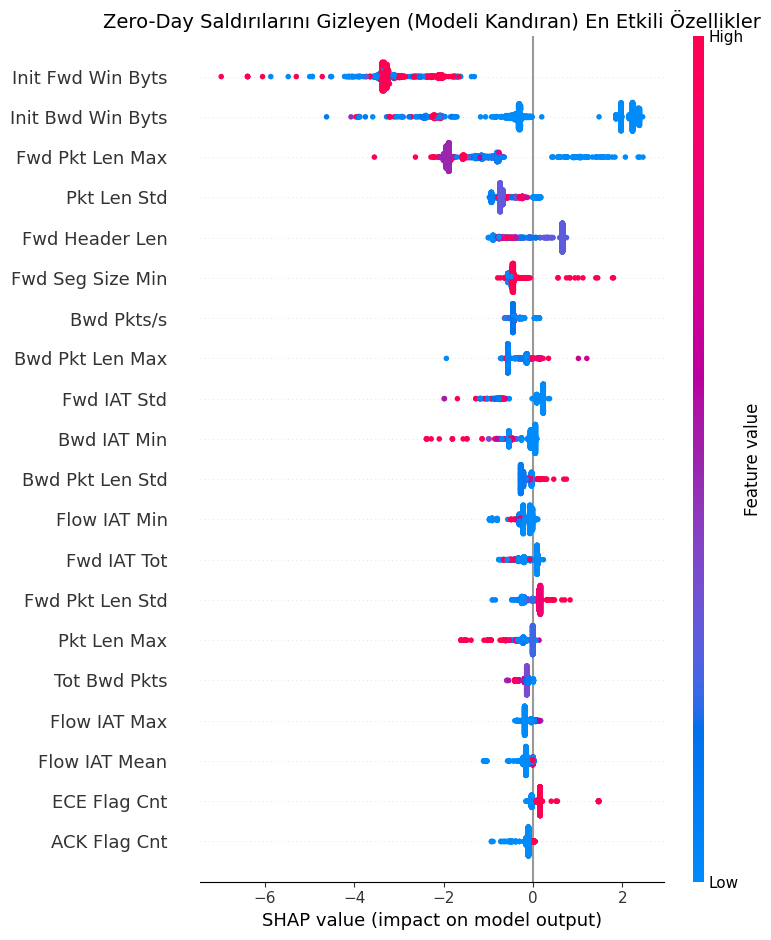


--- TEK BİR ZERO-DAY SALDIRISININ RÖNTGENİ ---
Bu grafikte, modelin neden bu pakete %50'nin altında (Normal) puan verdiğini göreceksin.


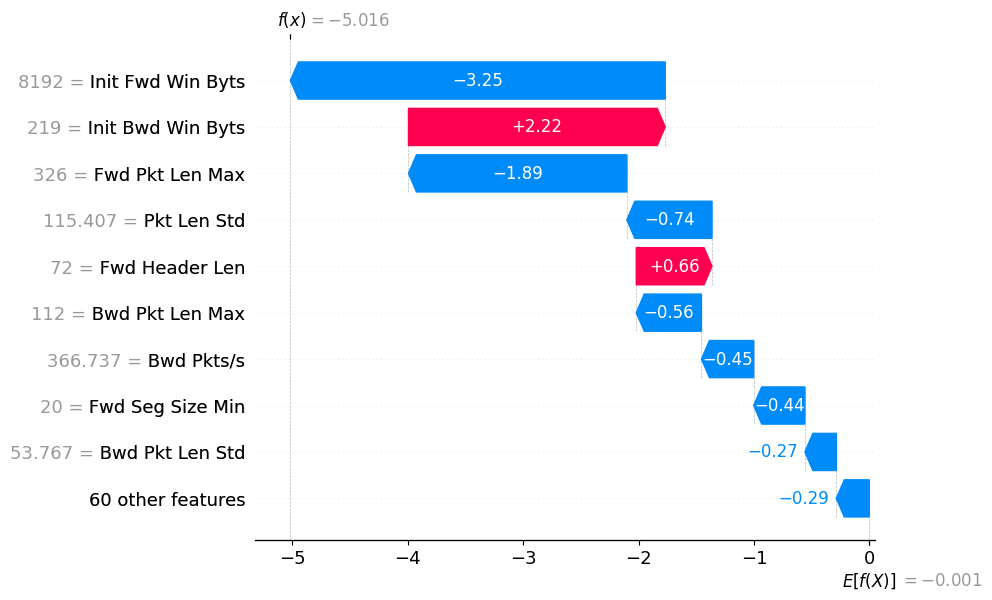

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Modeli ve Veriyi Yükleme
print("Veriler ve Model yükleniyor...")
X_test = pd.read_parquet('../data/splits/X_test.parquet')
y_test = pd.read_parquet('../data/splits/y_test.parquet')

xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../models/xgboost_zeroday.json')

# 2. Hatalı Tahminleri (False Negatives) İzole Etme
print("\nModelin tahminleri alınıyor...")
y_pred = xgb_model.predict(X_test)

# Gerçekte Saldırı (1) olan ama modelin Normal (0) dedikleri:
false_negative_mask = (y_test['Label'] == 1) & (y_pred == 0)
X_fn = X_test[false_negative_mask]

print(f"Toplam {X_fn.shape[0]} adet Zero-Day saldırısı 'Normal' zannedilerek içeri alınmış.")
print("Şimdi SHAP ile bunun 'NEDENİNİ' soruyoruz...\n")

# 3. SHAP Hesaplaması (TreeExplainer)
X_sample = X_fn.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)

# 4. Global Yorumlama: Summary Plot
plt.figure(figsize=(10, 8))
plt.title("Zero-Day Saldırılarını Gizleyen (Modeli Kandıran) En Etkili Özellikler", fontsize=14)
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 5. Yerel Yorumlama: Tek Bir Paketin Anatomisi (Waterfall Plot)
print("\n--- TEK BİR ZERO-DAY SALDIRISININ RÖNTGENİ ---")
print("Bu grafikte, modelin neden bu pakete %50'nin altında (Normal) puan verdiğini göreceksin.")
shap.plots.waterfall(shap_values[0])

Initial Forward/Backward Window Bytes (İleri ve Geri Yönlü Başlangıç TCP Pencere Boyutları) - Ezber yapmaya başlamasının sebebi ise Kali Linux ve Windows'un pencere boyutları farklıdır ve model sadece bu iki sütuna bakarak direkt Windows olanları normal, Kali olanlara saldırı demeye başladı.

Init Fwd Win Byts, Init Bwd Win Byts ve Fwd Pkt Len Max sütunları ezbere sebep olduğundan bu sütünları sil